In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

In [16]:
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

α (shape) = 1.3993
θ (scale) = 0.7146
media     = 1.0000  (debe ser ~1.0)


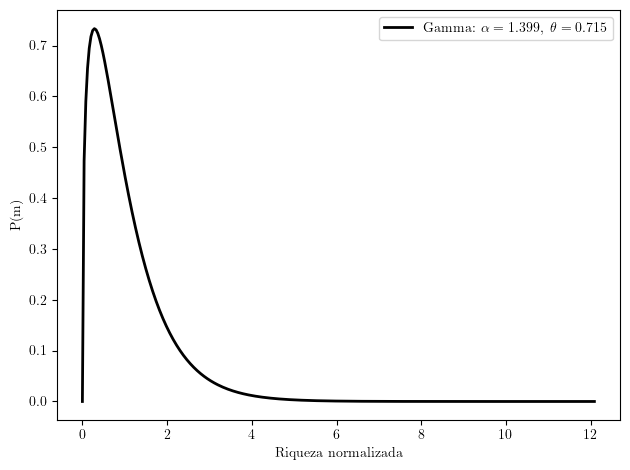


KS stat = 0.0129,  p-value = 0.0000


In [18]:
from scipy.stats import gamma

M = 5e4
N = 500
data = np.load('Pm_lamb0.1.npy') / (M/N)

bins = np.linspace(0, data.max(), 51)
bin_centers = (bins[:-1] + bins[1:]) / 2

densities = np.array([
    np.histogram(data[i], bins=bins, density=True)[0]
    for i in range(data.shape[0])
])
density_mean = densities.mean(axis=0)

# Ajuste gamma sobre todos los datos aplanados
data_flat = data.flatten()
alpha, loc, scale = gamma.fit(data_flat, floc=0)  # loc=0 fijo

print(f"α (shape) = {alpha:.4f}")
print(f"θ (scale) = {scale:.4f}")
print(f"media     = {alpha * scale:.4f}  (debe ser ~1.0)")

# Curva ajustada
x_fit = np.linspace(0, bin_centers.max(), 300)
y_fit = gamma.pdf(x_fit, a=alpha, loc=0, scale=scale)

# Graficar
#plt.bar(bin_centers, density_mean, width=np.diff(bins),
 #       color='coral', edgecolor='white', linewidth=0.5, label='Promedio histogramas')
plt.plot(x_fit, y_fit, 'k-', lw=2,
         label=fr'Gamma: $\alpha={alpha:.3f},\ \theta={scale:.3f}$')

plt.xlabel('Riqueza normalizada')
plt.ylabel('P(m)')
plt.legend()
plt.tight_layout()
plt.show()

# Bondad de ajuste
from scipy.stats import kstest
stat, p = kstest(data_flat, 'gamma', args=(alpha, 0, scale))
print(f"\nKS stat = {stat:.4f},  p-value = {p:.4f}")

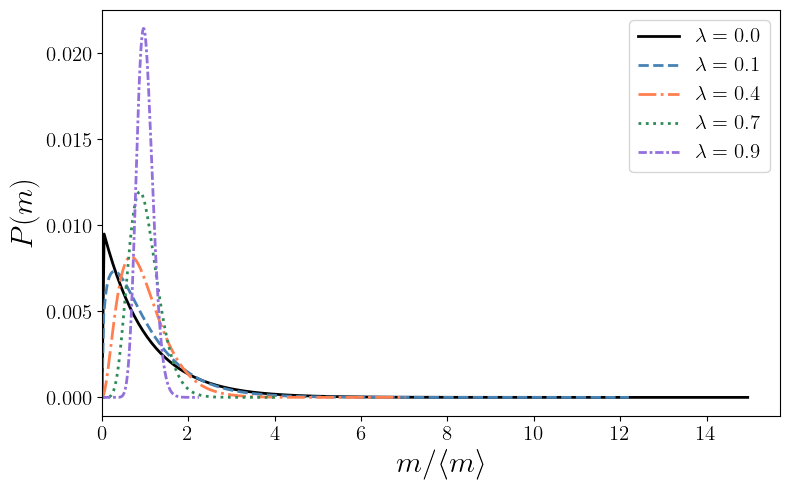

In [24]:
from scipy.stats import gamma
import numpy as np
import matplotlib.pyplot as plt

M = 5e4
N = 500

lambdas  = [0.0, 0.1, 0.4, 0.7, 0.9]
colors   = ['black', 'steelblue', 'coral', 'seagreen', 'mediumpurple']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")

for lamb, color, ls in zip(lambdas, colors, linestyles):
    data = np.load(f'Pm_lamb{lamb:.1f}.npy') / (M/N)
    data_flat = data.flatten()
    
    alpha, loc, scale = gamma.fit(data_flat, floc=0)
    
    x_fit = np.linspace(0, data.max(), 300)
    y_fit = gamma.pdf(x_fit, a=alpha, loc=0, scale=scale)
    
    ax.plot(x_fit, y_fit/100, color=color, lw=2, linestyle=ls,
            label=fr'$\lambda={lamb:.1f}$')

ax.set_xlim(left=0)
ax.set_xlabel(r'$m/\langle m \rangle$', fontsize=22)
ax.set_ylabel(r'$P(m)$', fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

ax.legend(fontsize=15)
plt.tight_layout()
plt.savefig('P_Full.pdf', bbox_inches='tight')
plt.show()